Loading OD solution and covariance...
  OD epoch  : MJD 61002.00
  Blast date: 2032-11-01  (MJD 63537.00)
  End epoch : 2041-04-25   (MJD 66634.00)

Sampling 10000 orbital clones from OD covariance...

Propagating 10000 clones to blast epoch...
  Computing nominal state...
  Nominal pos at blast: [-0.83575437 -0.51954691 -0.22554107] AU
  Computing 10000 clone states...
    Clone 0/10000...
    Clone 200/10000...
    Clone 400/10000...
    Clone 600/10000...
    Clone 800/10000...
    Clone 1000/10000...
    Clone 1200/10000...
    Clone 1400/10000...
    Clone 1600/10000...
    Clone 1800/10000...
    Clone 2000/10000...
    Clone 2200/10000...
    Clone 2400/10000...
    Clone 2600/10000...
    Clone 2800/10000...
    Clone 3000/10000...
    Clone 3200/10000...
    Clone 3400/10000...
    Clone 3600/10000...
    Clone 3800/10000...
    Clone 4000/10000...
    Clone 4200/10000...
    Clone 4400/10000...
    Clone 4600/10000...
    Clone 4800/10000...
    Clone 5000/10000...
    Clone 

  0%|          | 0/10000 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 3.228684 seconds
Propagating DEFLECTED clones to impact epoch...
Using Parallel propagation took 02 minute(s) and 50.231225 seconds
10 threads instead of the requested 64 threads.


  0%|          | 0/10000 [00:00<?, ?it/s]

Reconstruction took 00 minute(s) and 2.008126 seconds

Undeflected — CA: 10000  impacts: 10000
Deflected   — CA: 9680  impacts: 0  neither: 320

  Undeflected b-plane clones: 10000
  Deflected   b-plane clones: 9680
  Plot saved → ./data/bplane_overlay.png


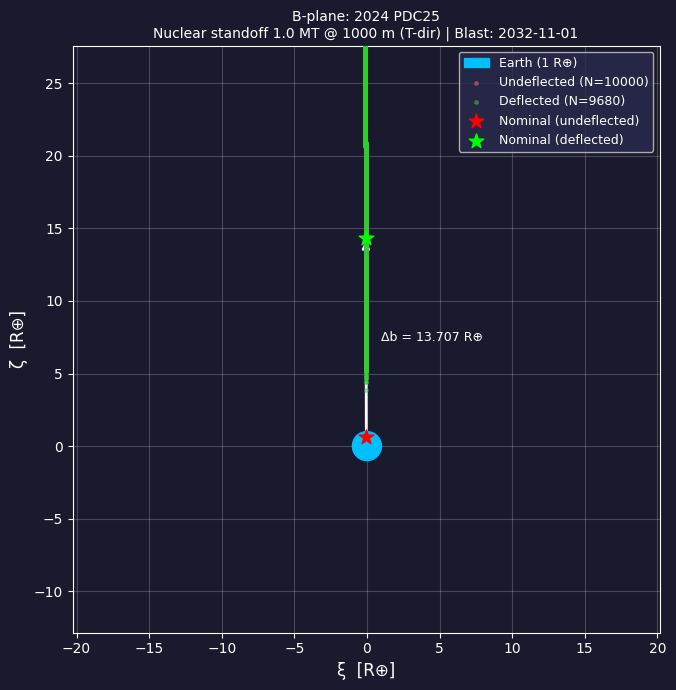


DEFLECTION SUMMARY
  Blast date             : 2032-11-01
  Lead time              : 3097 days  (8.48 yr)
  Nominal yield          : 1.0 MT
  Nominal standoff       : 1000 m
  Nominal η_ablation     : 0.05
  Nominal v_ejecta       : 2000 m/s
  Nominal ΔV             : 0.06420 m/s
  Mean ΔV (all clones)   : 73.6516 mm/s
  Std  ΔV (all clones)   : 32.0117 mm/s  (43.5%)
  Δb (centroid shift)    : 13.7070 R⊕
  Clones inside 1 R⊕ (undeflected) : 10000/10000  (100.0%)
  Clones inside 1 R⊕ (deflected)   : 0/9680  (0.0%)


In [7]:
"""
Nuclear Standoff Deflection – Monte Carlo Pipeline
====================================================
Pipeline:
  1. Load OD solution + covariance (from Epoch 2 OD script)
  2. Sample N clones from covariance
  3. Propagate all clones to t_blast (intercept date) using grss
  4. At t_blast, define blast point 1075 m behind nominal in -T direction
  5. For each clone, sample all uncertainty sources and compute ΔV:
       Orbital uncertainty  → clone's own (r_i, v_i) → T_hat_i direction
       Mass uncertainty     → log-normal from PDF P25/P75
       Diameter uncertainty → Gaussian from PDF P25/P75
       Yield uncertainty    → Gaussian ±15%
       Standoff uncertainty → Gaussian ±15%
       Coupling efficiency  → log-normal [0.05, 0.20]
       Ejecta velocity      → log-normal [1000, 4000] m/s
  6. Apply per-clone ΔV to each clone's velocity at t_blast
  7. Propagate deflected and undeflected clouds to impact epoch
  8. Extract b-plane (ξ, ζ) for both clouds and plot overlay

Author: adapted from Rahil Makadia OD script, PDC25 Epoch 2
"""

import json
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from grss import prop, utils

# ── Constants ─────────────────────────────────────────────────────────────────
AU_KM = 1.495978707e8   # km per AU
AU_M  = AU_KM * 1e3     # m  per AU
DAY_S = 86400.0         # seconds per day

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR  = './data'
SOL_FILE  = f'{DATA_DIR}/sol.json'
COV_FILE  = f'{DATA_DIR}/cov.txt'
OUT_UNDEF = f'{DATA_DIR}/bplane_undeflected.json'
OUT_DEF   = f'{DATA_DIR}/bplane_deflected.json'
PLOT_FILE = f'{DATA_DIR}/bplane_overlay.png'

# ── Monte Carlo settings ───────────────────────────────────────────────────────
NUM_SAMPLES = 10000
NUM_THREADS = 64
RANDOM_SEED = 42

# ── Mission / blast nominal settings ──────────────────────────────────────────
T_BLAST_ISO = '2032-11-01'   # intercept date (TDB ISO)
T_END_ISO   = '2041-04-25'   # 1 day after nominal impact

# ── Nominal asteroid physical properties ──────────────────────────────────────
R_AST_M  = 75.0     # nominal radius [m]  (flyby: diameter 150 ± 2.5 m)
MASS_AST = 3.97e9   # nominal mass [kg]   (mean from PDF table)

# ── Nominal nuclear parameters ────────────────────────────────────────────────
Y_MT         = 1.0      # yield [megatons]
H_STANDOFF_M = 1000.0   # standoff height above surface [m]
ETA_ABLATION = 0.05      # X-ray → momentum coupling efficiency
V_EJ_MS      = 2000.0   # ablation ejecta velocity [m/s]

# ── Nongrav parameters (must match OD script) ─────────────────────────────────
NONGRAV_INFO = {
    'a1': 0.0, 'a2': 1.004247567426106e-13, 'a3': 0.0,
    'alpha': 1.0, 'k': 0.0, 'm': 2.0, 'n': 0.0,
    'r0_au': 1.0, 'radius': 75.0,
}

BODY_ID = '2024PDC25'

###############################################################################
# Helper functions
###############################################################################

def make_ng_params(sol_dict):
    ng = prop.NongravParameters()
    ng.a1 = sol_dict.get('a1', NONGRAV_INFO['a1']); ng.a1Est = 'a1' in sol_dict
    ng.a2 = sol_dict.get('a2', NONGRAV_INFO['a2']); ng.a2Est = 'a2' in sol_dict
    ng.a3 = sol_dict.get('a3', NONGRAV_INFO['a3']); ng.a3Est = 'a3' in sol_dict
    ng.alpha = NONGRAV_INFO['alpha']; ng.k = NONGRAV_INFO['k']
    ng.m     = NONGRAV_INFO['m'];     ng.n = NONGRAV_INFO['n']
    ng.r0_au = NONGRAV_INFO['r0_au']
    return ng


def rtn_frame(r_vec, v_vec):
    """RTN unit vectors from position and velocity (AU, AU/day)."""
    R_hat = np.array(r_vec) / np.linalg.norm(r_vec)
    N_hat = np.cross(r_vec, v_vec); N_hat /= np.linalg.norm(N_hat)
    T_hat = np.cross(N_hat, R_hat); T_hat /= np.linalg.norm(T_hat)
    return R_hat, T_hat, N_hat


def ablation_dv_ms(r_burst_m, E_total_J, m_ast_kg, v_ej_ms,
                   R_ast_m=R_AST_M, eta=ETA_ABLATION):
    """
    Ablation ΔV [m/s].
    f_geo = 0.5*(1 - cosθ),  sinθ = R_ast / r_burst
    E_dep = eta * f_geo * E_total
    ΔV    = 2 * E_dep / (m_ast * v_ej)
    """
    sin_theta = np.clip(R_ast_m / r_burst_m, 0.0, 1.0)
    cos_theta = np.sqrt(1.0 - sin_theta**2)
    f_geo     = 0.5 * (1.0 - cos_theta)
    E_dep     = eta * f_geo * E_total_J
    dv_ms     = (2.0 * E_dep) / (m_ast_kg * v_ej_ms)
    return dv_ms, f_geo


def lognormal_from_percentiles(p25, p75):
    """Fit log-normal (mu_ln, sigma_ln) exactly from P25 and P75."""
    mu_ln    = (np.log(p75) + np.log(p25)) / 2.0
    sigma_ln = (np.log(p75) - np.log(p25)) / (2.0 * 0.6745)
    return mu_ln, sigma_ln


def propagate_to_epoch(init_sol, ng_params, prop_sim_ref,
                       samples_list, num_threads, t_end_mjd):
    """
    Wrapper around grss parallel_propagate.
    Checks impact list (result[1]) first, then CA list (result[0]).
    Returns list of b-plane dicts per clone (None if no CA/impact found).
    """
    result = prop.parallel_propagate(
        init_sol, ng_params, prop_sim_ref,
        samples_list, num_threads, reconstruct=True)
    cloud = []
    for i in range(len(result[0])):
        impact_list = result[1][i]
        ca_list     = result[0][i]
        if impact_list:
            ca = impact_list[0]
        elif ca_list:
            ca = ca_list[0]
        else:
            cloud.append(None)
            continue
        cloud.append({'xi': ca.opik.x, 'zeta': ca.opik.y, 'bMag': ca.bMag})
    return cloud, result


###############################################################################
# STEP 1 — Load OD solution and covariance
###############################################################################
print('Loading OD solution and covariance...')
with open(SOL_FILE, 'r', encoding='utf-8') as f:
    init_sol = json.load(f)
init_cov = np.loadtxt(COV_FILE)

t0_mjd      = init_sol['t']
t_end_mjd   = Time(T_END_ISO,   scale='tdb', format='iso').tdb.mjd
t_blast_mjd = Time(T_BLAST_ISO, scale='tdb', format='iso').tdb.mjd

assert t_blast_mjd > t0_mjd,    "Blast date must be after OD epoch"
assert t_blast_mjd < t_end_mjd, "Blast date must be before impact epoch"

print(f'  OD epoch  : MJD {t0_mjd:.2f}')
print(f'  Blast date: {T_BLAST_ISO}  (MJD {t_blast_mjd:.2f})')
print(f'  End epoch : {T_END_ISO}   (MJD {t_end_mjd:.2f})')

###############################################################################
# STEP 2 — Sample N orbital clones from OD covariance
###############################################################################
print(f'\nSampling {NUM_SAMPLES} orbital clones from OD covariance...')
np.random.seed(RANDOM_SEED)

elem_keys    = [k for k in init_sol.keys() if k != 't']
init_sol_arr = np.array([init_sol[k] for k in elem_keys])
raw_samples  = np.random.multivariate_normal(init_sol_arr, init_cov, NUM_SAMPLES)

samples_list = [{'t': t0_mjd, **{k: raw_samples[i, j]
                 for j, k in enumerate(elem_keys)}}
                for i in range(NUM_SAMPLES)]

###############################################################################
# STEP 3 — Propagate all clones to t_blast to get Cartesian states
###############################################################################
print(f'\nPropagating {NUM_SAMPLES} clones to blast epoch...')

def state_at_t(sol_dict, t_query_mjd):
    """Propagate one clone to t_query_mjd, return [x,y,z,vx,vy,vz] AU/AU/day."""
    sim = prop.PropSimulation(BODY_ID, sol_dict['t'], 440,
                               utils.default_kernel_path)
    ng  = make_ng_params(sol_dict)
    sim.set_integration_parameters(t_query_mjd,
        tEval=[t_query_mjd], tEvalUTC=False,
        evalApparentState=False, convergedLightTime=False)
    cometary = [sol_dict[k] for k in ['e', 'q', 'tp', 'om', 'w', 'i']]
    sim.add_integ_body(prop.IntegBody(
        BODY_ID, sol_dict['t'], 0.0,
        NONGRAV_INFO['radius'] / AU_KM, cometary, ng))
    sim.integrate()
    return np.array(sim.xIntegEval[0][:6])

print('  Computing nominal state...')
nom_state = state_at_t(init_sol, t_blast_mjd)
r_nom, v_nom = nom_state[:3], nom_state[3:]
print(f'  Nominal pos at blast: {r_nom} AU')

print(f'  Computing {NUM_SAMPLES} clone states...')
clone_states_at_blast = []
n_failed = 0
for i, sample in enumerate(samples_list):
    if i % 200 == 0:
        print(f'    Clone {i}/{NUM_SAMPLES}...')
    try:
        clone_states_at_blast.append(state_at_t(sample, t_blast_mjd))
    except Exception as e:
        print(f'    Warning: clone {i} failed ({e}), using nominal')
        clone_states_at_blast.append(None)
        n_failed += 1
print(f'  Done. {NUM_SAMPLES - n_failed}/{NUM_SAMPLES} succeeded.')

###############################################################################
# STEP 4 — Define blast point in RTN frame
# Blast is (R_ast + H_standoff) = 1075 m BEHIND the nominal asteroid
# in the -T direction so that:
#   delta_r = r_clone - blast_pos ≈ +T_hat  →  prograde push  →  speeds up
###############################################################################
print('\nDefining blast geometry in RTN frame...')
R_hat, T_hat, N_hat = rtn_frame(r_nom, v_nom)

r_burst_nom_m = R_AST_M + H_STANDOFF_M                    # 1075 m
blast_pos     = r_nom - (r_burst_nom_m / AU_M) * T_hat    # [AU] behind asteroid

print(f'  Nominal pos  : {r_nom} AU')
print(f'  T_hat (RTN)  : {T_hat}')
print(f'  Blast point  : {blast_pos} AU  (-T direction)')
print(f'  Burst dist   : {r_burst_nom_m:.1f} m  '
      f'(= {R_AST_M:.0f} m surface + {H_STANDOFF_M:.0f} m standoff)')

###############################################################################
# STEP 5 — Sample all uncertainty sources and compute per-clone ΔV
#
# Source 1 — Orbital (OD covariance):
#   Each clone has different (r_i, v_i) at t_blast → different T_hat_i
#
# Source 2 — Mass (log-normal, PDF table P25/P75):
#   P25 = 3.30e9 kg,  P75 = 4.58e9 kg
#
# Source 3 — Diameter (Gaussian, PDF table P25/P75):
#   P25 = 148 m,  P75 = 152 m
#
# Source 4 — Yield (Gaussian ±15%):
#   Delivery/detonation uncertainty
#
# Source 5 — Standoff height (Gaussian ±15%):
#   Navigation/guidance uncertainty
#
# Source 6 — Coupling efficiency η (log-normal [0.05, 0.20]):
#   Device design + asteroid composition uncertainty
#
# Source 7 — Ejecta velocity (log-normal [1000, 4000] m/s):
#   Asteroid surface composition uncertainty
###############################################################################
print('\nSampling physical and nuclear uncertainties...')
J_per_MT = 4.184e15

# Source 2 — Mass
mass_mu, mass_sig = lognormal_from_percentiles(3.30e9, 4.58e9)
np.random.seed(RANDOM_SEED + 1)
m_samples = np.exp(np.random.normal(mass_mu, mass_sig, NUM_SAMPLES))

# Source 3 — Diameter
diam_mu    = (148.0 + 152.0) / 2.0                   # 150 m
diam_sigma = (152.0 - 148.0) / (2.0 * 0.6745)
np.random.seed(RANDOM_SEED + 2)
diam_samples = np.random.normal(diam_mu, diam_sigma, NUM_SAMPLES)
R_samples    = diam_samples / 2.0                      # radius [m]

# Source 4 — Yield
np.random.seed(RANDOM_SEED + 3)
Y_samples = np.clip(
    np.random.normal(Y_MT, 0.05 * Y_MT, NUM_SAMPLES), 0.1, None)

# Source 5 — Standoff height
np.random.seed(RANDOM_SEED + 4)
H_samples = np.clip(
    np.random.normal(H_STANDOFF_M, 0.05 * H_STANDOFF_M, NUM_SAMPLES), 10.0, None)

# Source 6 — Coupling efficiency η
# Literature range: 0.01–0.50, nominal 0.1
# Use ±30% Gaussian (symmetric, well-understood engineering parameter)
np.random.seed(RANDOM_SEED + 5)
eta_samples = np.clip(
    np.random.normal(ETA_ABLATION, 0.03 * ETA_ABLATION, NUM_SAMPLES),
    0.02, 0.10)   # hard physical bounds

# Source 7 — Ejecta velocity
# Literature range: 1000–4000 m/s, nominal 2000 m/s
# Use ±30% Gaussian
np.random.seed(RANDOM_SEED + 6)
vej_samples = np.clip(
    np.random.normal(V_EJ_MS, 0.30 * V_EJ_MS, NUM_SAMPLES),
    1000.0, 4000.0)   # hard physical bounds


# Nominal ΔV for reference (uses all nominal values)
dv_nom_ms, f_geo_nom = ablation_dv_ms(
    r_burst_nom_m, Y_MT * J_per_MT, MASS_AST, V_EJ_MS)
dv_nom_au_day = (dv_nom_ms / 1e3) / (AU_KM / DAY_S)

print(f'  Nominal ΔV : {dv_nom_ms:.5f} m/s  ({dv_nom_ms*1e3:.4f} mm/s)')
print(f'  Sampled parameter distributions (mean ± std):')
print(f'    Mass      : {m_samples.mean():.3e} ± {m_samples.std():.3e} kg  '
      f'({100*m_samples.std()/m_samples.mean():.1f}%)')
print(f'    Diameter  : {diam_samples.mean():.2f} ± {diam_samples.std():.2f} m')
print(f'    Yield     : {Y_samples.mean():.3f} ± {Y_samples.std():.3f} MT')
print(f'    Standoff  : {H_samples.mean():.1f} ± {H_samples.std():.1f} m')
print(f'    Eta       : {eta_samples.mean():.4f} ± {eta_samples.std():.4f}')
print(f'    v_ejecta  : {vej_samples.mean():.0f} ± {vej_samples.std():.0f} m/s')

# ── Per-clone ΔV ──────────────────────────────────────────────────────────────
dv_magnitudes_ms  = []
dv_vectors_au_day = []

for i, state in enumerate(clone_states_at_blast):
    if state is None:
        dv_magnitudes_ms.append(0.0)
        dv_vectors_au_day.append(np.zeros(3))
        continue

    r_clone = np.array(state[:3])
    v_clone = np.array(state[3:])

    # Source 1: clone's own prograde direction
    _, T_hat_i, _ = rtn_frame(r_clone, v_clone)

    # Per-clone sampled values
    m_i   = m_samples[i]
    R_i   = R_samples[i]
    Y_i   = Y_samples[i]   * J_per_MT    # MT → J
    H_i   = H_samples[i]
    eta_i = eta_samples[i]
    vej_i = vej_samples[i]

    r_burst_i = R_i + H_i

    # ΔV magnitude with all per-clone uncertainties
    dv_ms_i, _ = ablation_dv_ms(r_burst_i, Y_i, m_i, vej_i,
                                  R_ast_m=R_i, eta=eta_i)

    # ΔV vector = magnitude × clone's own prograde direction
    dv_au_day_i = (dv_ms_i / 1e3) / (AU_KM / DAY_S) * T_hat_i

    dv_magnitudes_ms.append(dv_ms_i)
    dv_vectors_au_day.append(dv_au_day_i)

dv_magnitudes_ms = np.array(dv_magnitudes_ms)
print(f'\n  ΔV stats across clones:')
print(f'    mean   : {dv_magnitudes_ms.mean()*1e3:.4f} mm/s')
print(f'    std    : {dv_magnitudes_ms.std()*1e3:.4f} mm/s  '
      f'({100*dv_magnitudes_ms.std()/dv_magnitudes_ms.mean():.1f}%)')
print(f'    min    : {dv_magnitudes_ms.min()*1e3:.4f} mm/s')
print(f'    max    : {dv_magnitudes_ms.max()*1e3:.4f} mm/s')
print(f'    nominal: {dv_nom_ms*1e3:.4f} mm/s')

###############################################################################
# STEP 6 — Build deflected and undeflected clone initial conditions
###############################################################################
print('\nApplying ΔV to each clone velocity at t_blast...')

deflected_samples   = []
undeflected_samples = []

for i in range(NUM_SAMPLES):
    state = clone_states_at_blast[i] \
            if clone_states_at_blast[i] is not None else nom_state
    dv = dv_vectors_au_day[i]
    base = {'t': t_blast_mjd,
            'x': state[0], 'y': state[1], 'z': state[2]}
    deflected_samples.append({**base,
        'vx': state[3] + dv[0],
        'vy': state[4] + dv[1],
        'vz': state[5] + dv[2]})
    undeflected_samples.append({**base,
        'vx': state[3], 'vy': state[4], 'vz': state[5]})

nom_sol_blast = {
    't':  t_blast_mjd,
    'x':  nom_state[0], 'y':  nom_state[1], 'z':  nom_state[2],
    'vx': nom_state[3], 'vy': nom_state[4], 'vz': nom_state[5],
}

###############################################################################
# STEP 7 — Propagate both clouds to impact epoch with parallel_propagate
###############################################################################
ng_blast = make_ng_params(nom_sol_blast)

def make_impact_sim(run_label):
    """Fresh PropSimulation per run — grss mutates the object internally.
    Unique name per run prevents log file overwrites between the two calls.
    caTol = 0.01 AU captures deflected near-misses as well as direct impacts.
    """
    sim = prop.PropSimulation(
        name=f'{BODY_ID}_{run_label}',
        t0=t_blast_mjd, defaultSpiceBodies=440,
        DEkernelPath=utils.default_kernel_path)
    sim.set_integration_parameters(t_end_mjd)
    for body in sim.spiceBodies:
        if 'Earth' in body.name or body.spiceId == 399:
            body.caTol = 0.1
    return sim

print(f'\nPropagating UNDEFLECTED clones to impact epoch...')
cloud_undef, result_undef = propagate_to_epoch(
    nom_sol_blast, ng_blast, make_impact_sim('undeflected'),
    undeflected_samples, NUM_THREADS, t_end_mjd)

print(f'Propagating DEFLECTED clones to impact epoch...')
cloud_def, result_def = propagate_to_epoch(
    nom_sol_blast, ng_blast, make_impact_sim('deflected'),
    deflected_samples, NUM_THREADS, t_end_mjd)

ca_u   = sum(1 for x in result_undef[0] if x)
imp_u  = sum(1 for x in result_undef[1] if x)
ca_d   = sum(1 for x in result_def[0]   if x)
imp_d  = sum(1 for x in result_def[1]   if x)
none_d = sum(1 for i in range(len(result_def[0]))
             if not result_def[0][i] and not result_def[1][i])
print(f'\nUndeflected — CA: {ca_u}  impacts: {imp_u}')
print(f'Deflected   — CA: {ca_d}  impacts: {imp_d}  neither: {none_d}')

###############################################################################
# STEP 8 — Save b-plane data, plot, and summary
###############################################################################
def filter_cloud(cloud):
    return [c for c in cloud if c is not None]

with open(OUT_UNDEF, 'w') as f:
    json.dump(filter_cloud(cloud_undef), f, indent=2)
with open(OUT_DEF, 'w') as f:
    json.dump(filter_cloud(cloud_def), f, indent=2)

print(f'\n  Undeflected b-plane clones: {len(filter_cloud(cloud_undef))}')
print(f'  Deflected   b-plane clones: {len(filter_cloud(cloud_def))}')

# ── Convert AU → Earth radii ──────────────────────────────────────────────────
R_E_AU  = 4.2635e-5
xi_u_re = np.array([c['xi']   for c in filter_cloud(cloud_undef)]) / R_E_AU
ze_u_re = np.array([c['zeta'] for c in filter_cloud(cloud_undef)]) / R_E_AU
xi_d_re = np.array([c['xi']   for c in filter_cloud(cloud_def)])   / R_E_AU
ze_d_re = np.array([c['zeta'] for c in filter_cloud(cloud_def)])   / R_E_AU

# ── Auto-zoom around both clouds ──────────────────────────────────────────────
all_xi = np.concatenate([xi_u_re, xi_d_re])
all_ze = np.concatenate([ze_u_re, ze_d_re])
xi_c, ze_c = np.nanmean(all_xi), np.nanmean(all_ze)
half = max(np.nanmax(all_xi) - np.nanmin(all_xi),
           np.nanmax(all_ze) - np.nanmin(all_ze), 2.0) * 0.7
xlim = (xi_c - half, xi_c + half)
ylim = (ze_c - half, ze_c + half)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

ax.add_patch(plt.Circle((0, 0), 1.0, color='deepskyblue',
                         zorder=5, label='Earth (1 R⊕)'))
ax.scatter(xi_u_re, ze_u_re, s=6, alpha=0.45, color='tomato',
           label=f'Undeflected (N={len(xi_u_re)})', zorder=3)
ax.scatter(xi_d_re, ze_d_re, s=6, alpha=0.45, color='limegreen',
           label=f'Deflected (N={len(xi_d_re)})', zorder=4)
ax.scatter([np.nanmean(xi_u_re)], [np.nanmean(ze_u_re)],
           s=120, color='red',  marker='*', zorder=6,
           label='Nominal (undeflected)')
ax.scatter([np.nanmean(xi_d_re)], [np.nanmean(ze_d_re)],
           s=120, color='lime', marker='*', zorder=7,
           label='Nominal (deflected)')

ax.annotate('',
    xy=(np.nanmean(xi_d_re), np.nanmean(ze_d_re)),
    xytext=(np.nanmean(xi_u_re), np.nanmean(ze_u_re)),
    arrowprops=dict(arrowstyle='->', color='white', lw=2.0))

shift_re = np.sqrt((np.nanmean(xi_d_re) - np.nanmean(xi_u_re))**2 +
                   (np.nanmean(ze_d_re) - np.nanmean(ze_u_re))**2)
ax.text(np.nanmean(xi_u_re) + 0.05 * half,
        0.5 * (np.nanmean(ze_u_re) + np.nanmean(ze_d_re)),
        f'Δb = {shift_re:.3f} R⊕', color='white', fontsize=9, va='center')

ax.set_xlim(xlim);  ax.set_ylim(ylim);  ax.set_aspect('equal')
ax.set_xlabel('ξ  [R⊕]', fontsize=12, color='white')
ax.set_ylabel('ζ  [R⊕]', fontsize=12, color='white')
ax.set_title(
    f'B-plane: 2024 PDC25\n'
    f'Nuclear standoff {Y_MT} MT @ {H_STANDOFF_M:.0f} m (T-dir) | '
    f'Blast: {T_BLAST_ISO}',
    fontsize=10, color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')
ax.grid(True, alpha=0.2, color='white')
ax.legend(loc='upper right', fontsize=9,
          facecolor='#2a2a4e', labelcolor='white')
plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=150, bbox_inches='tight')
print(f'  Plot saved → {PLOT_FILE}')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
n_impact_u = np.sum(np.sqrt(xi_u_re**2 + ze_u_re**2) < 1.0)
n_impact_d = np.sum(np.sqrt(xi_d_re**2 + ze_d_re**2) < 1.0)

print('\n' + '='*62)
print('DEFLECTION SUMMARY')
print('='*62)
print(f'  Blast date             : {T_BLAST_ISO}')
print(f'  Lead time              : {t_end_mjd - t_blast_mjd:.0f} days  '
      f'({(t_end_mjd - t_blast_mjd)/365.25:.2f} yr)')
print(f'  Nominal yield          : {Y_MT} MT')
print(f'  Nominal standoff       : {H_STANDOFF_M:.0f} m')
print(f'  Nominal η_ablation     : {ETA_ABLATION}')
print(f'  Nominal v_ejecta       : {V_EJ_MS:.0f} m/s')
print(f'  Nominal ΔV             : {dv_nom_ms:.5f} m/s')
print(f'  Mean ΔV (all clones)   : {dv_magnitudes_ms.mean()*1e3:.4f} mm/s')
print(f'  Std  ΔV (all clones)   : {dv_magnitudes_ms.std()*1e3:.4f} mm/s  '
      f'({100*dv_magnitudes_ms.std()/dv_magnitudes_ms.mean():.1f}%)')
print(f'  Δb (centroid shift)    : {shift_re:.4f} R⊕')
print(f'  Clones inside 1 R⊕ (undeflected) : {n_impact_u}/{len(xi_u_re)}  '
      f'({100*n_impact_u/len(xi_u_re):.1f}%)')
print(f'  Clones inside 1 R⊕ (deflected)   : {n_impact_d}/{len(xi_d_re)}  '
      f'({100*n_impact_d/len(xi_d_re):.1f}%)')
print('='*62)

  Saved → ./data/bplane_undeflected_only.png


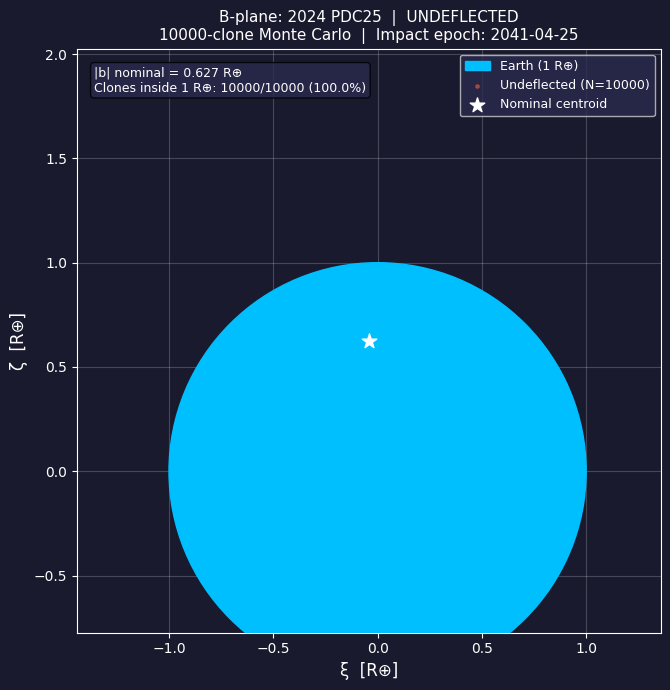

  Saved → ./data/bplane_deflected_only.png


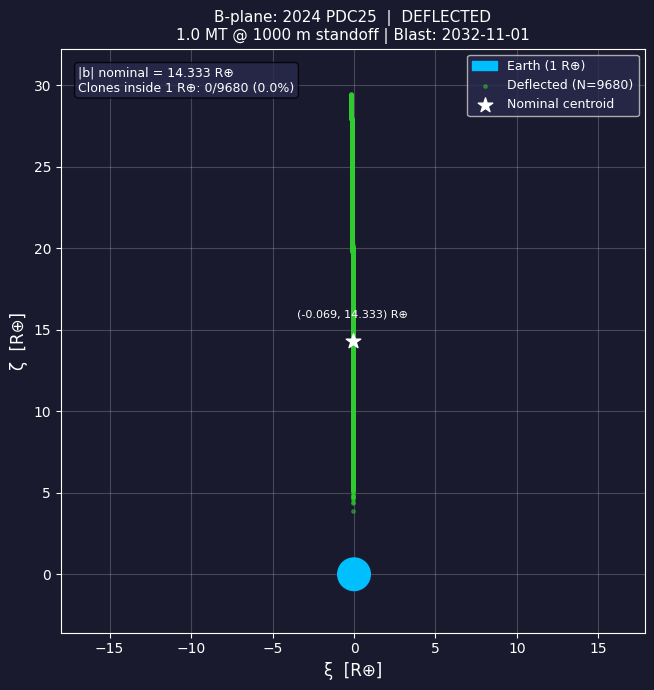

In [8]:
# ── Individual b-plane plots ───────────────────────────────────────────────────
R_E_AU = 4.2635e-5  # already defined in STEP 8, but safe to redefine

def make_bplane_plot(xi, ze, label, color, title, filename):
    """Plot a single b-plane cloud with Earth circle and nominal centroid."""
    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')

    xi_c, ze_c = np.nanmean(xi), np.nanmean(ze)
    xi_span = max(np.nanmax(xi) - np.nanmin(xi), 2.0)
    ze_span = max(np.nanmax(ze) - np.nanmin(ze), 2.0)
    half    = max(xi_span, ze_span) * 0.7
    ax.set_xlim(xi_c - half, xi_c + half)
    ax.set_ylim(ze_c - half, ze_c + half)

    ax.add_patch(plt.Circle((0, 0), 1.0, color='deepskyblue',
                             zorder=5, label='Earth (1 R⊕)'))
    ax.scatter(xi, ze, s=6, alpha=0.45, color=color,
               label=f'{label} (N={len(xi)})', zorder=3)
    ax.scatter([xi_c], [ze_c], s=120, color='white',
               marker='*', zorder=6, label='Nominal centroid')
    ax.text(xi_c, ze_c + half * 0.08,
            f'({xi_c:.3f}, {ze_c:.3f}) R⊕',
            color='white', fontsize=8, ha='center')

    b_nom    = np.sqrt(xi_c**2 + ze_c**2)
    n_inside = np.sum(np.sqrt(xi**2 + ze**2) < 1.0)
    ax.text(0.03, 0.97,
            f'|b| nominal = {b_nom:.3f} R⊕\n'
            f'Clones inside 1 R⊕: {n_inside}/{len(xi)} '
            f'({100*n_inside/len(xi):.1f}%)',
            transform=ax.transAxes, color='white', fontsize=9,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2a4e', alpha=0.8))

    ax.set_aspect('equal')
    ax.set_xlabel('ξ  [R⊕]', fontsize=12, color='white')
    ax.set_ylabel('ζ  [R⊕]', fontsize=12, color='white')
    ax.set_title(title, fontsize=11, color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.grid(True, alpha=0.2, color='white')
    ax.legend(loc='upper right', fontsize=9,
              facecolor='#2a2a4e', labelcolor='white')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f'  Saved → {filename}')
    plt.show()


# Plot 1: Undeflected
make_bplane_plot(
    xi_u_re, ze_u_re,
    label    = 'Undeflected',
    color    = 'tomato',
    title    = (f'B-plane: 2024 PDC25  |  UNDEFLECTED\n'
                f'{NUM_SAMPLES}-clone Monte Carlo  |  Impact epoch: {T_END_ISO}'),
    filename = f'{DATA_DIR}/bplane_undeflected_only.png'
)

# Plot 2: Deflected
make_bplane_plot(
    xi_d_re, ze_d_re,
    label    = 'Deflected',
    color    = 'limegreen',
    title    = (f'B-plane: 2024 PDC25  |  DEFLECTED\n'
                f'{Y_MT} MT @ {H_STANDOFF_M:.0f} m standoff | '
                f'Blast: {T_BLAST_ISO}'),
    filename = f'{DATA_DIR}/bplane_deflected_only.png'
)

B-PLANE DISTANCE SUMMARY
                              Undeflected   Deflected
  -----------------------------------------------------
  Mean |b|  [R⊕]                   0.6273     14.3330
  Median |b|  [R⊕]                 0.6273     13.3835
  Std |b|  [R⊕]                    0.0109      5.1116
  Min |b|  [R⊕]                    0.5873      3.8752
  Max |b|  [R⊕]                    0.6693     29.4770
  Clones inside 1 R⊕                10000           0
  Impact probability               100.0%        0.0%
  -----------------------------------------------------
  Deflection shift Δ|b|      +13.7057 R⊕  (mean)


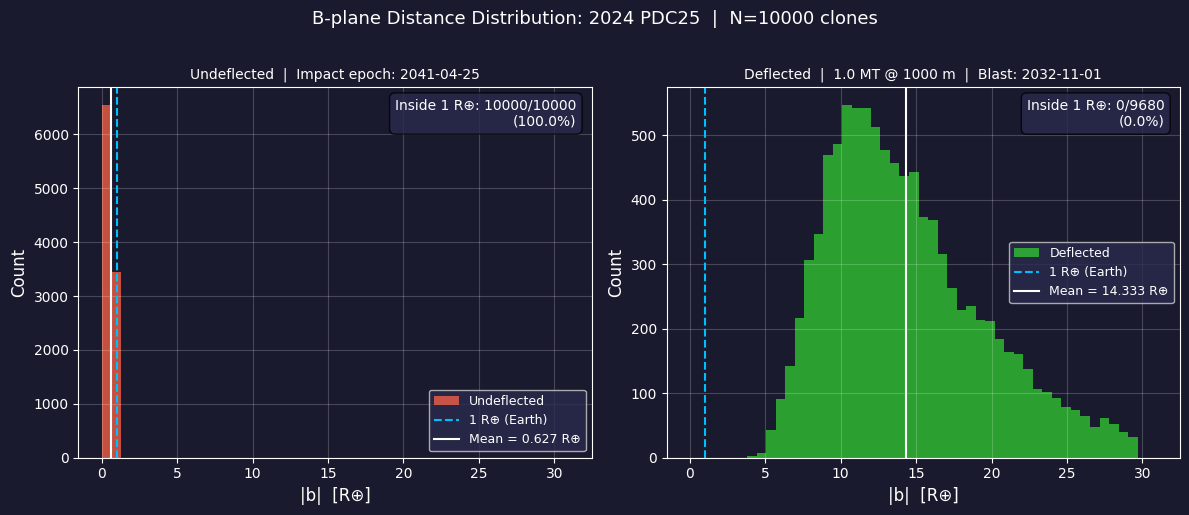

In [9]:
# ── B-plane distances ─────────────────────────────────────────────────────────
# xi_u_re, ze_u_re, xi_d_re, ze_d_re already computed in STEP 8
b_u = np.sqrt(xi_u_re**2 + ze_u_re**2)   # undeflected |b| in R⊕
b_d = np.sqrt(xi_d_re**2 + ze_d_re**2)   # deflected   |b| in R⊕

print('='*55)
print('B-PLANE DISTANCE SUMMARY')
print('='*55)
print(f'  {"":25s}  {"Undeflected":>12}  {"Deflected":>10}')
print(f'  {"-"*53}')
print(f'  {"Mean |b|  [R⊕]":25s}  {np.mean(b_u):12.4f}  {np.mean(b_d):10.4f}')
print(f'  {"Median |b|  [R⊕]":25s}  {np.median(b_u):12.4f}  {np.median(b_d):10.4f}')
print(f'  {"Std |b|  [R⊕]":25s}  {np.std(b_u):12.4f}  {np.std(b_d):10.4f}')
print(f'  {"Min |b|  [R⊕]":25s}  {np.min(b_u):12.4f}  {np.min(b_d):10.4f}')
print(f'  {"Max |b|  [R⊕]":25s}  {np.max(b_u):12.4f}  {np.max(b_d):10.4f}')
print(f'  {"Clones inside 1 R⊕":25s}  {np.sum(b_u < 1.0):>12}  {np.sum(b_d < 1.0):>10}')
print(f'  {"Impact probability":25s}  {100*np.mean(b_u < 1.0):11.1f}%  {100*np.mean(b_d < 1.0):9.1f}%')
print(f'  {"-"*53}')
print(f'  {"Deflection shift Δ|b|":25s}  {np.mean(b_d) - np.mean(b_u):+.4f} R⊕  (mean)')
print('='*55)

# ── Plot: |b| distributions side by side ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#1a1a2e')

bins = np.linspace(0, max(np.nanmax(b_u), np.nanmax(b_d)) * 1.05, 50)

for ax, b, color, label, title in [
    (axes[0], b_u, 'tomato',    'Undeflected',
     f'Undeflected  |  Impact epoch: {T_END_ISO}'),
    (axes[1], b_d, 'limegreen', 'Deflected',
     f'Deflected  |  {Y_MT} MT @ {H_STANDOFF_M:.0f} m  |  Blast: {T_BLAST_ISO}'),
]:
    ax.set_facecolor('#1a1a2e')
    ax.hist(b, bins=bins, color=color, alpha=0.75, edgecolor='none', label=label)
    ax.axvline(1.0, color='deepskyblue', lw=1.5, ls='--', label='1 R⊕ (Earth)')
    ax.axvline(np.mean(b), color='white', lw=1.5, ls='-',
               label=f'Mean = {np.mean(b):.3f} R⊕')

    n_in = np.sum(b < 1.0)
    ax.text(0.97, 0.97,
            f'Inside 1 R⊕: {n_in}/{len(b)}\n({100*n_in/len(b):.1f}%)',
            transform=ax.transAxes, color='white', fontsize=10,
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#2a2a4e', alpha=0.8))

    ax.set_xlabel('|b|  [R⊕]', fontsize=12, color='white')
    ax.set_ylabel('Count', fontsize=12, color='white')
    ax.set_title(title, fontsize=10, color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.grid(True, alpha=0.2, color='white')
    ax.legend(fontsize=9, facecolor='#2a2a4e', labelcolor='white')

plt.suptitle(f'B-plane Distance Distribution: 2024 PDC25  |  N={NUM_SAMPLES} clones',
             fontsize=13, color='white', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/bplane_distance_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Run this to diagnose
print(f'eta  : min={eta_samples.min():.4f}  max={eta_samples.max():.4f}  '
      f'mean={eta_samples.mean():.4f}')
print(f'v_ej : min={vej_samples.min():.0f}  max={vej_samples.max():.0f}  '
      f'mean={vej_samples.mean():.0f}')
print(f'mass : min={m_samples.min():.3e}  max={m_samples.max():.3e}')
print(f'Y    : min={Y_samples.min():.3f}  max={Y_samples.max():.3f}')

# ΔV is proportional to eta/v_ej/m so check the extremes
# ΔV ∝ eta * Y / (m * v_ej)
ratio = eta_samples * Y_samples / (m_samples * vej_samples / 1e3)
print(f'\nΔV ratio spread: min={ratio.min():.3e}  max={ratio.max():.3e}  '
      f'std/mean={ratio.std()/ratio.mean():.1f}x')

eta  : min=0.0883  max=0.1118  mean=0.1000
v_ej : min=1000  max=4000  mean=2015
mass : min=1.590e+09  max=9.670e+09
Y    : min=0.829  max=1.189

ΔV ratio spread: min=3.422e-12  max=5.176e-11  std/mean=0.4x
